### News convertation to embeddings (length 3072)

In [ ]:
import ollama
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time
import warnings
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import ast
from joblib import dump

from sklearn.decomposition import PCA
#import eikon as ek
#ek.set_app_key('KEY')

#from sentence_transformers import SentenceTransformer


In [2]:
model_id = "llama3.2"

In [3]:
df = pd.read_csv('/Users/andaks/Columbia/Columbia Fall24/LLMM/2024_2025_raw_headlines')
df = df[['timeIssued', 'headline']].dropna()

In [4]:
df

,timeIssued,headline
0,2025-04-13 23:25:00.880,U.S. REFINERY FILING - PORT ARTHUR REFINERY ...
1,2025-04-13 11:23:53.000,"UPDATE 1-Saudi Arabia, US on 'pathway' to civi..."
2,2025-04-13 09:42:57.000,US and Saudi Arabia to sign agreement on energ...
3,2025-04-13 09:24:36.531,RIYADH - U.S. ENERGY SECRETARY SAYS THERE WILL...
4,2025-04-13 09:21:36.293,RIYADH - U.S. ENERGY SECRETARY SAYS FURTHER DE...
...,...,...
20882,2024-01-19 11:50:01.418,"SLB Q4 ADJUSTED EBITDA USD 2,277 MILLION VS. I..."
20883,2024-01-19 11:24:05.000,"US STOCKS-Futures climb as chips, megacaps gai..."
20884,2024-01-17 17:47:12.000,BUZZ-US energy sector falls on demand concerns...
20885,2024-01-17 14:22:38.000,"BUZZ-Oil firms fall on demand concerns, strong..."


In [5]:
i = 0
def get_embeddings(text):
    result = ollama.embeddings(model=model_id, prompt=text)["embedding"]
    global i
    print(i)
    i += 1
    return result

# Apply the function to each row in the DataFrame and store embeddings in a new column
df['emb'] = df['headline'].apply(get_embeddings)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201


KeyboardInterrupt: 

In [135]:
#df.to_csv('/Users/andaks/Columbia Fall24/LLMM/df_news.csv', index=False)
df = pd.read_csv('/Users/andaks/Columbia/Columbia Fall24/LLMM/df_news.csv')
df

,timeIssued,headline,emb
0,2024-10-06 23:55:40.671,NHC STORM ADVISORY: milton expected to become ...,"[-1.567741870880127, 0.9038830995559692, 1.976..."
1,2024-10-06 20:52:45.559,NHC STORM ADVISORY: milton continuing to rapid...,"[-0.7699227929115295, -1.1515058279037476, 0.7..."
2,2024-10-06 20:36:40.903,NHC STORM ADVISORY: Kirk spreading large swell...,"[-0.6443654894828796, -0.502163290977478, 1.81..."
3,2024-10-06 20:34:30.570,NHC STORM ADVISORY: Leslie heading northwestward,"[0.2092490792274475, -0.46833884716033936, 1.9..."
4,2024-10-06 17:48:00.656,NHC STORM ADVISORY: Air Force Hurricane hunter...,"[0.324649840593338, 0.03929061442613602, -2.84..."
...,...,...,...
13330,2023-07-11 13:22:29.000,"BUZZ-U.S. STOCKS ON THE MOVE-VeriSign, Equitra...","[1.4034918546676636, 0.831781804561615, 0.0806..."
13331,2023-07-11 12:21:41.000,BUZZ-Rosenblatt cuts Disney PT as 'Indiana Jon...,"[-3.0251119136810303, 0.11785916239023209, 3.6..."
13332,2023-07-11 11:11:33.602,WALT DISNEY CO <DIS.N>: ROSENBLATT SECURITIES ...,"[0.10605094581842422, 1.39973783493042, 0.5012..."
13333,2024-04-08 05:47:17.000,JAPAN FORMER TOP FX OFFICIAL NAKAO: RECENT SPE...,"[-0.01868174970149994, 0.6540576219558716, 1.6..."


In [217]:
df = df.sort_values(by='timeIssued')
df = df[df['timeIssued'] >= '2024-07-22']

Only features [news time, embedding]

In [218]:
df_f = df[['timeIssued', 'emb']]

### Add historical Crude prices from Eikon (Refinitiv Workspace)

In [219]:
df1 = pd.read_excel('/Users/andaks/Downloads/Price History_20250411_0101 XOM.xlsx').drop(columns = ['Local Date'])
# df2 = pd.read_excel('/Users/andaks/Downloads/Price History_20241008_0053.xlsx').drop(columns = ['Local Date'])
# df3 = pd.read_excel('/Users/andaks/Downloads/Price History_20241008_0055.xlsx').drop(columns = ['Local Date'])
# df4 = pd.read_excel('/Users/andaks/Downloads/Price History_20241008_0057.xlsx').drop(columns = ['Local Date'])
# df5 = pd.read_excel('/Users/andaks/Downloads/Price History_20241008_0058.xlsx').drop(columns = ['Local Date'])
df1.head(5)
#df_g_p = pd.concat([df1, df2, df3, df4, df5])
df_g_p = df1[['Local Time', 'Open', 'Close']]

# # Reset the index if needed
df_g_p.reset_index(drop=True, inplace=True)

In [220]:
df_g_p

,Local Time,Open,Close
0,2024-10-09 19:59:00,NaN,NaN
1,2024-10-09 19:58:00,122.1200,122.1200
2,2024-10-09 19:57:00,NaN,NaN
3,2024-10-09 19:51:00,122.1200,122.1200
4,2024-10-09 19:48:00,122.1200,122.1200
...,...,...,...
43195,2024-07-22 16:02:00,114.6082,115.2507
43196,2024-07-22 16:01:00,114.6082,114.6082
43197,2024-07-22 16:00:00,115.3300,115.2750
43198,2024-07-22 15:59:00,115.3350,115.3201


In [221]:
df_f

,timeIssued,emb
8270,2024-07-22 04:30:00.000,"[-0.3248223662376404, 0.1169494241476059, 3.06..."
2636,2024-07-22 08:01:10.000,"[0.5481522679328918, -1.018620252609253, -1.19..."
8269,2024-07-22 08:01:10.000,"[0.5481522679328918, -1.018620252609253, -1.19..."
8268,2024-07-22 08:44:49.000,"[-1.6728463172912598, 0.8270439505577087, 1.96..."
2635,2024-07-22 08:46:27.000,"[-0.4674503803253174, 0.2560778260231018, 3.17..."
...,...,...
3,2024-10-06 20:34:30.570,"[0.2092490792274475, -0.46833884716033936, 1.9..."
2,2024-10-06 20:36:40.903,"[-0.6443654894828796, -0.502163290977478, 1.81..."
1,2024-10-06 20:52:45.559,"[-0.7699227929115295, -1.1515058279037476, 0.7..."
5300,2024-10-06 21:45:00.000,"[0.8037936687469482, -1.8932108879089355, 2.44..."


In [222]:
df_f.sort_values(by = 'timeIssued')

,timeIssued,emb
8270,2024-07-22 04:30:00.000,"[-0.3248223662376404, 0.1169494241476059, 3.06..."
2636,2024-07-22 08:01:10.000,"[0.5481522679328918, -1.018620252609253, -1.19..."
8269,2024-07-22 08:01:10.000,"[0.5481522679328918, -1.018620252609253, -1.19..."
8268,2024-07-22 08:44:49.000,"[-1.6728463172912598, 0.8270439505577087, 1.96..."
2635,2024-07-22 08:46:27.000,"[-0.4674503803253174, 0.2560778260231018, 3.17..."
...,...,...
3,2024-10-06 20:34:30.570,"[0.2092490792274475, -0.46833884716033936, 1.9..."
2,2024-10-06 20:36:40.903,"[-0.6443654894828796, -0.502163290977478, 1.81..."
1,2024-10-06 20:52:45.559,"[-0.7699227929115295, -1.1515058279037476, 0.7..."
5300,2024-10-06 21:45:00.000,"[0.8037936687469482, -1.8932108879089355, 2.44..."


We have to merge two datasets. 
+ We are a bit limited because we know gold price only by rough minutes while news have seconds.
+ to fix that let's say news happen in the beginning of the minute t = 0 (if it happened between 0 and 1). So the last price before that is the minute 0 (bid+ask)/2. It will be "staring" price. End price is (bid+ask)/2 t = 5. 
+ I imply that news imformation fully included in the price in 5 minutes.

In [223]:
# convert time, drop seconds as described above

df_f['timeIssued'] = pd.to_datetime(df_f['timeIssued'])
df_f['timeIssued'] = df_f['timeIssued'].dt.floor('T')

df_g_p['Local Time'] = pd.to_datetime(df_g_p['Local Time'])

/var/folders/gh/dfjmmnfn63s_k8hfzrv1t9m40000gn/T/ipykernel_2034/3939846286.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_f['timeIssued'] = pd.to_datetime(df_f['timeIssued'])
/var/folders/gh/dfjmmnfn63s_k8hfzrv1t9m40000gn/T/ipykernel_2034/3939846286.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_f['timeIssued'] = df_f['timeIssued'].dt.floor('T')
/var/folders/gh/dfjmmnfn63s_k8hfzrv1t9m40000gn/T/ipykernel_2034/3939846286.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

In [224]:
df_f

,timeIssued,emb
8270,2024-07-22 04:30:00,"[-0.3248223662376404, 0.1169494241476059, 3.06..."
2636,2024-07-22 08:01:00,"[0.5481522679328918, -1.018620252609253, -1.19..."
8269,2024-07-22 08:01:00,"[0.5481522679328918, -1.018620252609253, -1.19..."
8268,2024-07-22 08:44:00,"[-1.6728463172912598, 0.8270439505577087, 1.96..."
2635,2024-07-22 08:46:00,"[-0.4674503803253174, 0.2560778260231018, 3.17..."
...,...,...
3,2024-10-06 20:34:00,"[0.2092490792274475, -0.46833884716033936, 1.9..."
2,2024-10-06 20:36:00,"[-0.6443654894828796, -0.502163290977478, 1.81..."
1,2024-10-06 20:52:00,"[-0.7699227929115295, -1.1515058279037476, 0.7..."
5300,2024-10-06 21:45:00,"[0.8037936687469482, -1.8932108879089355, 2.44..."


In [225]:
df_g_p

,Local Time,Open,Close
0,2024-10-09 19:59:00,NaN,NaN
1,2024-10-09 19:58:00,122.1200,122.1200
2,2024-10-09 19:57:00,NaN,NaN
3,2024-10-09 19:51:00,122.1200,122.1200
4,2024-10-09 19:48:00,122.1200,122.1200
...,...,...,...
43195,2024-07-22 16:02:00,114.6082,115.2507
43196,2024-07-22 16:01:00,114.6082,114.6082
43197,2024-07-22 16:00:00,115.3300,115.2750
43198,2024-07-22 15:59:00,115.3350,115.3201


In [226]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Convert the dataset descriptions to actual DataFrames
# This is a simulated recreation since we don't have the actual data
# Let's assume df_f and df_g_p are already loaded with the appropriate formats

# First, ensure the time columns are datetime objects
df_f['timeIssuede'] = pd.to_datetime(df_f['timeIssued'])
df_g_p['Local Time'] = pd.to_datetime(df_g_p['Local Time'])

# Create a new DataFrame for the result
result_df = pd.DataFrame()

# Add timestamp and emb from df_f
result_df['timestamp'] = df_f['timeIssued']
result_df['emb'] = df_f['emb']  # Assuming 'emb' is the second column in df_f

# For each row in df_f, find the closest price in df_g_p
prices = []
prices_5 = []
changes = []

for idx, row in df_f.iterrows():
    emb_time = row['timeIssued']
    
    # Find closest price entry (for current price)
    closest_price_idx = (df_g_p['Local Time'] - emb_time).abs().idxmin()
    closest_price = df_g_p.loc[closest_price_idx, 'Open']
    
    # Find price at least 5 minutes later
    five_min_later = emb_time + timedelta(minutes=5)
    future_prices = df_g_p[df_g_p['Local Time'] >= five_min_later]
    
    if not future_prices.empty:
        # Take the closest price that's at least 5 minutes later
        price_5_idx = (future_prices['Local Time'] - five_min_later).abs().idxmin()
        price_5 = future_prices.loc[price_5_idx, 'Close']
    else:
        price_5 = np.nan
    
    # Calculate change
    if pd.notna(closest_price) and pd.notna(price_5) and closest_price != 0:
        change = price_5 / closest_price - 1
    else:
        change = np.nan
    
    prices.append(closest_price)
    prices_5.append(price_5)
    changes.append(change)

# Add the calculated columns to the result DataFrame
result_df['price'] = prices
result_df['price_5'] = prices_5
result_df['change'] = changes

# Display the first few rows of the merged dataset
print(result_df.head())

/var/folders/gh/dfjmmnfn63s_k8hfzrv1t9m40000gn/T/ipykernel_2034/269375110.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_g_p['Local Time'] = pd.to_datetime(df_g_p['Local Time'])


               timestamp                                                emb  \
8270 2024-07-22 04:30:00  [-0.3248223662376404, 0.1169494241476059, 3.06...   
2636 2024-07-22 08:01:00  [0.5481522679328918, -1.018620252609253, -1.19...   
8269 2024-07-22 08:01:00  [0.5481522679328918, -1.018620252609253, -1.19...   
8268 2024-07-22 08:44:00  [-1.6728463172912598, 0.8270439505577087, 1.96...   
2635 2024-07-22 08:46:00  [-0.4674503803253174, 0.2560778260231018, 3.17...   

       price  price_5   change  
8270  115.38  115.335 -0.00039  
2636  115.38  115.335 -0.00039  
8269  115.38  115.335 -0.00039  
8268  115.38  115.335 -0.00039  
2635  115.38  115.335 -0.00039  


In [227]:
result_df.dropna(inplace=True)

In [228]:
result_df

,timestamp,emb,price,price_5,change
8270,2024-07-22 04:30:00,"[-0.3248223662376404, 0.1169494241476059, 3.06...",115.38,115.3350,-0.000390
2636,2024-07-22 08:01:00,"[0.5481522679328918, -1.018620252609253, -1.19...",115.38,115.3350,-0.000390
8269,2024-07-22 08:01:00,"[0.5481522679328918, -1.018620252609253, -1.19...",115.38,115.3350,-0.000390
8268,2024-07-22 08:44:00,"[-1.6728463172912598, 0.8270439505577087, 1.96...",115.38,115.3350,-0.000390
2635,2024-07-22 08:46:00,"[-0.4674503803253174, 0.2560778260231018, 3.17...",115.38,115.3350,-0.000390
...,...,...,...,...,...
75,2024-10-04 19:28:00,"[1.984501600265503, 2.6453585624694824, -0.052...",122.71,124.9145,0.017965
74,2024-10-04 19:28:00,"[1.5212209224700928, 1.9523037672042847, -0.12...",122.71,124.9145,0.017965
202,2024-10-04 19:28:00,"[-0.1402433067560196, -0.8547688126564026, 1.3...",122.71,124.9145,0.017965
73,2024-10-04 19:28:00,"[-0.1402433067560196, -0.8547688126564026, 1.3...",122.71,124.9145,0.017965


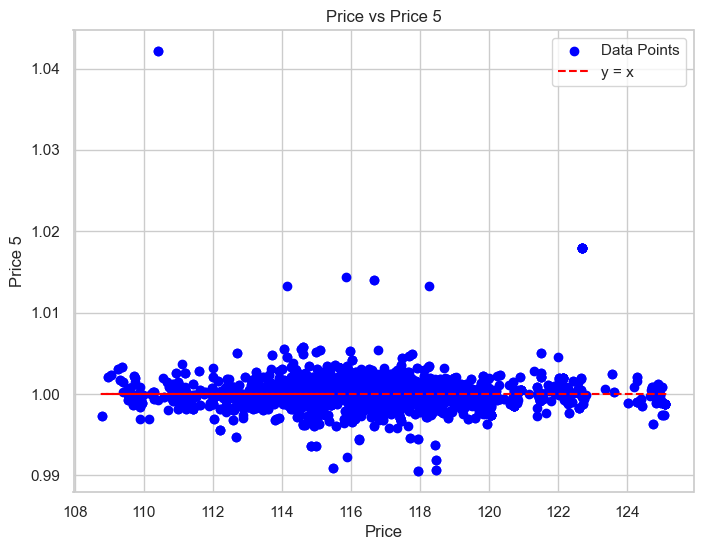

In [229]:
plt.figure(figsize=(8, 6))
plt.scatter(result_df['price'], result_df['price_5']/result_df['price'], color='blue', label='Data Points')
plt.plot(result_df['price'], result_df['price']/result_df['price'], color='red', linestyle='--', label='y = x')

# Adding labels and legend
plt.xlabel('Price')
plt.ylabel('Price 5')
plt.title('Price vs Price 5')
plt.legend()

# Show plot
plt.show()

In [230]:
result_df['change'] = result_df['change']*100

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


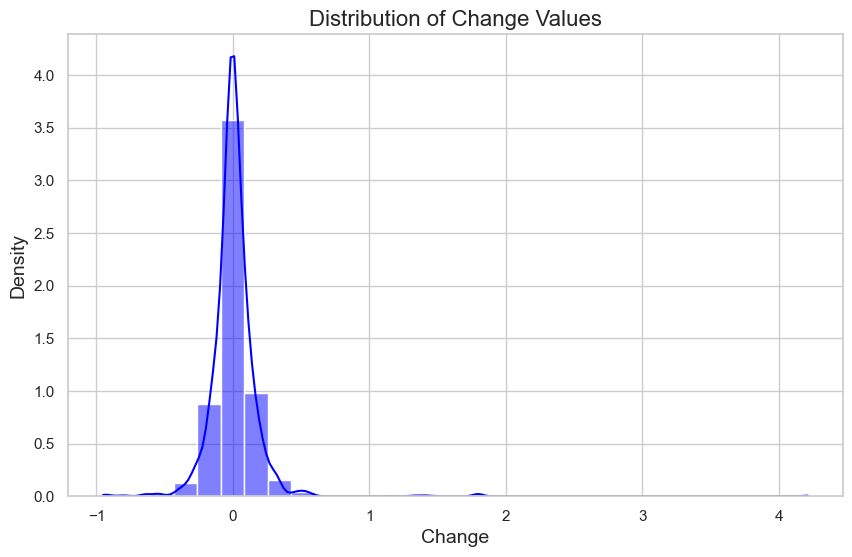

In [231]:
sns.set(style="whitegrid")

# Create a figure
plt.figure(figsize=(10, 6))

# Create a histogram
sns.histplot(result_df['change'], bins=30, kde=True, color='blue', stat='density')

# Add labels and title
plt.title('Distribution of Change Values', fontsize=16)
plt.xlabel('Change', fontsize=14)
plt.ylabel('Density', fontsize=14)

# Show the plot
plt.show()

# Now train model. Catboost

In [232]:
df_merged = result_df[['emb', 'change']]

In [233]:
df_merged['emb']

8270     [-0.3248223662376404, 0.1169494241476059, 3.06...
2636     [0.5481522679328918, -1.018620252609253, -1.19...
8269     [0.5481522679328918, -1.018620252609253, -1.19...
8268     [-1.6728463172912598, 0.8270439505577087, 1.96...
2635     [-0.4674503803253174, 0.2560778260231018, 3.17...
                               ...                        
75       [1.984501600265503, 2.6453585624694824, -0.052...
74       [1.5212209224700928, 1.9523037672042847, -0.12...
202      [-0.1402433067560196, -0.8547688126564026, 1.3...
73       [-0.1402433067560196, -0.8547688126564026, 1.3...
10300    [3.801241874694824, 0.29293590784072876, -0.12...
Name: emb, Length: 4108, dtype: object

In [234]:
def convert_to_array(list_str):
    # Convert the string to a list
    list_array = ast.literal_eval(list_str)
    # Convert the list to a NumPy array (optional, if you need it as a NumPy array)
    return np.array(list_array)

# Assuming your dataframe is df
# Apply the function to the "emb" column
df_merged['emb'] = df_merged['emb'].apply(convert_to_array)

/var/folders/gh/dfjmmnfn63s_k8hfzrv1t9m40000gn/T/ipykernel_2034/719017173.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['emb'] = df_merged['emb'].apply(convert_to_array)


In [235]:
df_merged['emb'].head(10)

8270     [-0.3248223662376404, 0.1169494241476059, 3.06...
2636     [0.5481522679328918, -1.018620252609253, -1.19...
8269     [0.5481522679328918, -1.018620252609253, -1.19...
8268     [-1.6728463172912598, 0.8270439505577087, 1.96...
2635     [-0.4674503803253174, 0.2560778260231018, 3.17...
8267     [-0.4674503803253174, 0.2560778260231018, 3.17...
10799    [-1.2133889198303223, 2.7101097106933594, 3.04...
10798    [-0.9059526324272156, 2.7742791175842285, 3.60...
10797    [-2.746009588241577, 0.4163055717945099, 5.284...
2633     [1.2727398872375488, 0.9370968341827393, 2.462...
Name: emb, dtype: object

In [305]:
df_merged_copy = df_merged.copy()
df_merged_copy = df_merged_copy[['emb', 'change']]

In [306]:
# Step 1: Convert the 'emb' column into a matrix
emb_matrix = np.vstack(df_merged_copy['emb'].values)

# Step 2: Apply PCA
k = 10
pca = PCA(n_components=k)  # Reduce to k components for visualization
emb_pca = pca.fit_transform(emb_matrix)

# Step 3: Add the PCA results back to the DataFrame
for i in range(k):
    df_merged_copy[f'PCA_{i+1}'] = emb_pca[:, i]

# Display the updated DataFrame
df_merged_copy.head()
print(f"PCA was applied to reduce dimensions from {emb_matrix.shape[1]} to {k}.")

PCA was applied to reduce dimensions from 3072 to 10.


In [307]:
# Save the PCA model to a file
dump(pca, 'pca_model.joblib')

['pca_model.joblib']

In [308]:
df_reserve = df_merged.copy()
df_merged = df_merged_copy

In [309]:
df_merged.head(5)

,emb,change,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10
8270,"[-0.3248223662376404, 0.1169494241476059, 3.06...",-0.039002,-27.586561,0.449056,12.370828,-0.847309,1.913246,-4.827454,-9.593011,-2.562991,-0.394672,-2.360193
2636,"[0.5481522679328918, -1.018620252609253, -1.19...",-0.039002,33.839360,29.844619,7.296963,0.967875,-20.264133,10.067651,-7.055315,-13.056541,-12.375614,6.911612
8269,"[0.5481522679328918, -1.018620252609253, -1.19...",-0.039002,33.839360,29.844619,7.296963,0.967875,-20.264133,10.067651,-7.055315,-13.056541,-12.375614,6.911612
8268,"[-1.6728463172912598, 0.8270439505577087, 1.96...",-0.039002,-23.883930,-3.871032,2.492795,-15.863904,9.254411,-13.107293,-7.050051,-2.825372,-6.897202,-1.912482
2635,"[-0.4674503803253174, 0.2560778260231018, 3.17...",-0.039002,-27.258714,-4.629942,8.715176,3.624445,7.999974,-5.200404,-7.635342,-0.586375,-4.574832,3.646284


In [310]:
df_merged

,emb,change,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10
8270,"[-0.3248223662376404, 0.1169494241476059, 3.06...",-0.039002,-27.586561,0.449056,12.370828,-0.847309,1.913246,-4.827454,-9.593011,-2.562991,-0.394672,-2.360193
2636,"[0.5481522679328918, -1.018620252609253, -1.19...",-0.039002,33.839360,29.844619,7.296963,0.967875,-20.264133,10.067651,-7.055315,-13.056541,-12.375614,6.911612
8269,"[0.5481522679328918, -1.018620252609253, -1.19...",-0.039002,33.839360,29.844619,7.296963,0.967875,-20.264133,10.067651,-7.055315,-13.056541,-12.375614,6.911612
8268,"[-1.6728463172912598, 0.8270439505577087, 1.96...",-0.039002,-23.883930,-3.871032,2.492795,-15.863904,9.254411,-13.107293,-7.050051,-2.825372,-6.897202,-1.912482
2635,"[-0.4674503803253174, 0.2560778260231018, 3.17...",-0.039002,-27.258714,-4.629942,8.715176,3.624445,7.999974,-5.200404,-7.635342,-0.586375,-4.574832,3.646284
...,...,...,...,...,...,...,...,...,...,...,...,...
75,"[1.984501600265503, 2.6453585624694824, -0.052...",1.796512,38.314837,2.132553,-8.277596,-6.555454,19.497016,8.610298,-9.630379,2.321310,-2.031325,-15.401613
74,"[1.5212209224700928, 1.9523037672042847, -0.12...",1.796512,39.601668,0.520107,-13.126779,-6.709230,17.639892,7.643220,-11.798953,4.067245,0.048515,-14.771322
202,"[-0.1402433067560196, -0.8547688126564026, 1.3...",1.796512,-13.071241,-5.749542,-11.693903,-7.964279,0.378889,3.543633,-8.732867,9.280219,-3.915464,-3.604400
73,"[-0.1402433067560196, -0.8547688126564026, 1.3...",1.796512,-13.071241,-5.749542,-11.693903,-7.964279,0.378889,3.543633,-8.732867,9.280219,-3.915464,-3.604400


In [311]:
# Step 3: Split the data into features (X) and target (y)
X = df_merged.drop(columns=['change', 'emb'])  # Features
y = df_merged['change']  # Target variable

# Step 4: Split the data into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Sort the data by index to ensure proper order
X = X.sort_index()
y = y.sort_index()

# Split the data into training and testing sets based on the first 80% and last 20%
split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
# Step 5: Initialize the CatBoostRegressor
model = CatBoostRegressor(iterations=2000, learning_rate=0.1, depth=7, silent=False)

# Step 6: Fit the model
model.fit(X_train, y_train)

# Step 7: Make predictions on the test set
predictions = model.predict(X_test)

mse = mean_squared_error(y_train, model.predict(X_train))
print(f'Mean Squared Error on train: {mse}')
# Step 8: Evaluate the model
mse = mean_squared_error(y_test, predictions)
print(f'Mean Squared Error on test: {mse}')

# Optional: Display predictions vs actual
results = pd.DataFrame({'Actual': y_test, 'Predicted': predictions})
print(results.head())


0:	learn: 0.1932759	total: 22.5ms	remaining: 45s
1:	learn: 0.1909014	total: 25.5ms	remaining: 25.4s
2:	learn: 0.1885537	total: 27.2ms	remaining: 18.1s
3:	learn: 0.1864694	total: 29.1ms	remaining: 14.5s
4:	learn: 0.1841867	total: 30.9ms	remaining: 12.3s
5:	learn: 0.1821024	total: 32.5ms	remaining: 10.8s
6:	learn: 0.1809769	total: 34.1ms	remaining: 9.7s
7:	learn: 0.1788735	total: 36.9ms	remaining: 9.19s
8:	learn: 0.1770833	total: 39.1ms	remaining: 8.64s
9:	learn: 0.1761714	total: 41.7ms	remaining: 8.3s
10:	learn: 0.1744902	total: 43.3ms	remaining: 7.82s
11:	learn: 0.1727842	total: 45.3ms	remaining: 7.51s
12:	learn: 0.1713450	total: 47.2ms	remaining: 7.21s
13:	learn: 0.1697601	total: 48.9ms	remaining: 6.93s
14:	learn: 0.1691887	total: 50.4ms	remaining: 6.67s
15:	learn: 0.1679112	total: 51.9ms	remaining: 6.44s
16:	learn: 0.1666067	total: 54.2ms	remaining: 6.32s
17:	learn: 0.1658777	total: 57.3ms	remaining: 6.31s
18:	learn: 0.1645290	total: 59.3ms	remaining: 6.18s
19:	learn: 0.1637912	total

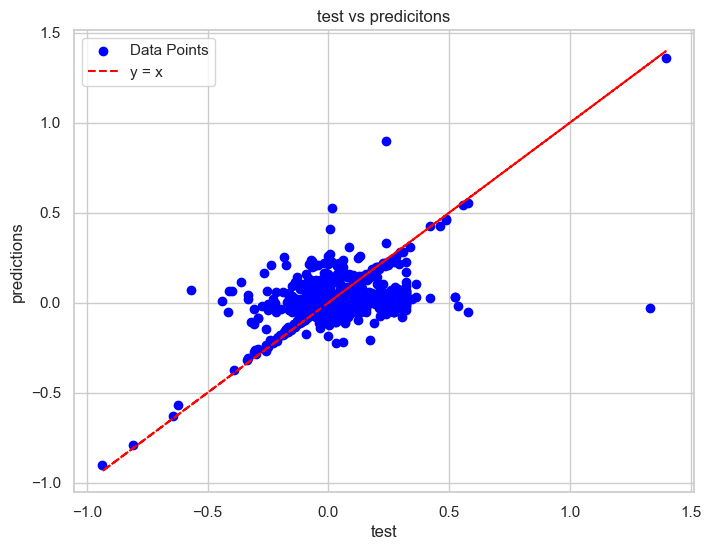

In [312]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, color='blue', label='Data Points')
plt.plot(y_test, y_test, color='red', linestyle='--', label='y = x')

# Adding labels and legend
plt.xlabel('test')
plt.ylabel('predictions')
plt.title('test vs predicitons')
plt.legend()

# Show plot
plt.show()

In [313]:
# Compare the signs of y_test and predictions
correct_signs = np.sign(y_test) == np.sign(predictions)

# Calculate the percentage of correct guesses
percentage_correct = correct_signs.sum() / len(y_test) * 100
print(f"Percentage of correctly guessed signs: {percentage_correct:.2f}%")

Percentage of correctly guessed signs: 65.21%


### save model weights

In [314]:
model.save_model('catboost_model_weights.cbm')

7 for this k/100 benchmark pnl is:


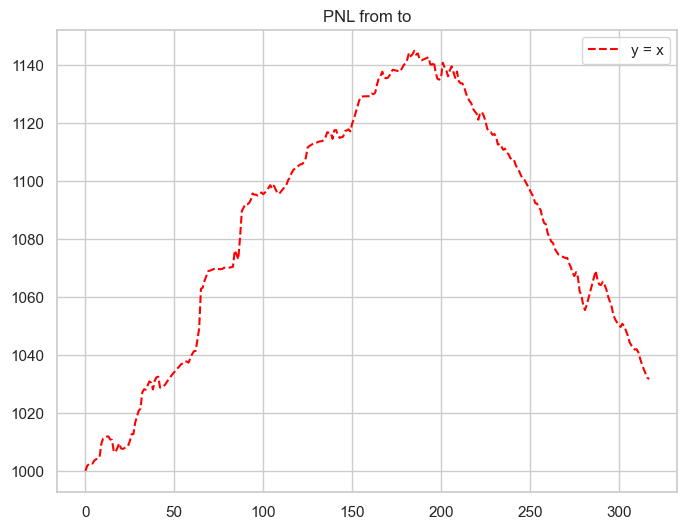

8 for this k/100 benchmark pnl is:


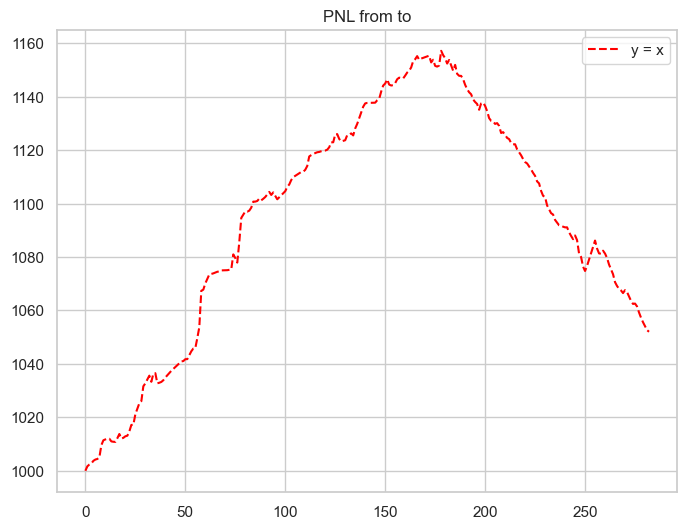

9 for this k/100 benchmark pnl is:


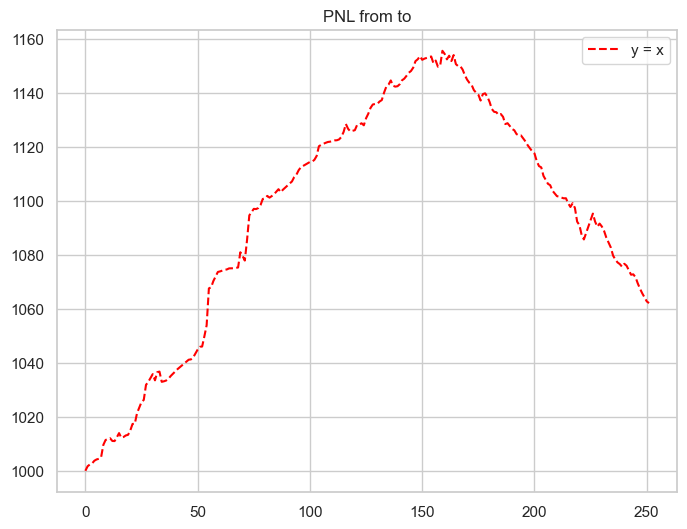

10 for this k/100 benchmark pnl is:


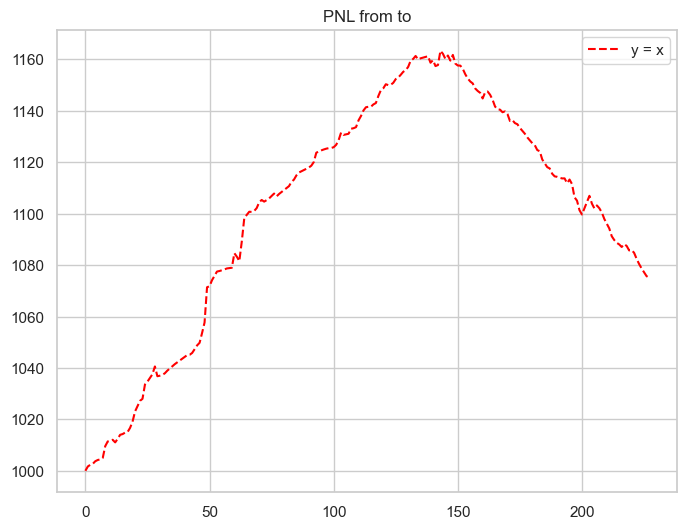

11 for this k/100 benchmark pnl is:


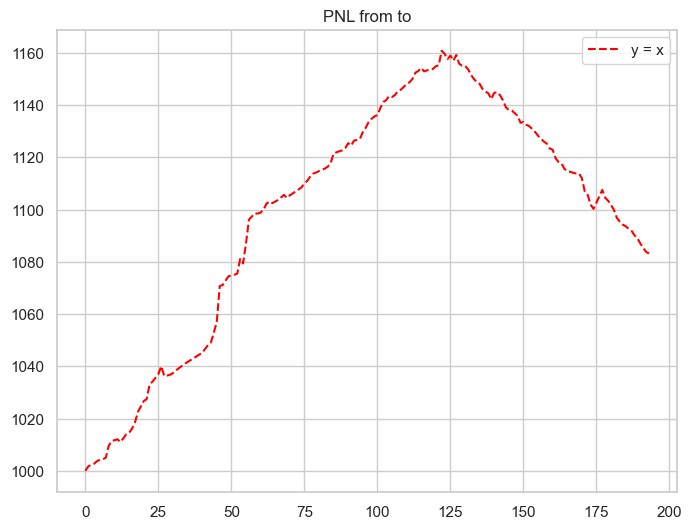

12 for this k/100 benchmark pnl is:


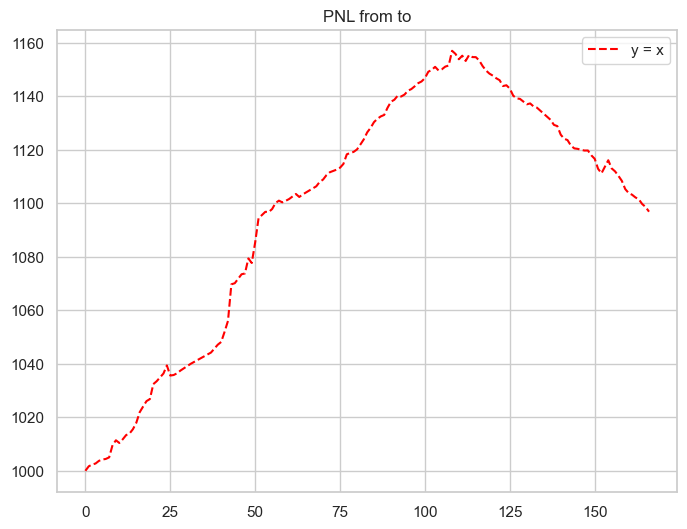

13 for this k/100 benchmark pnl is:


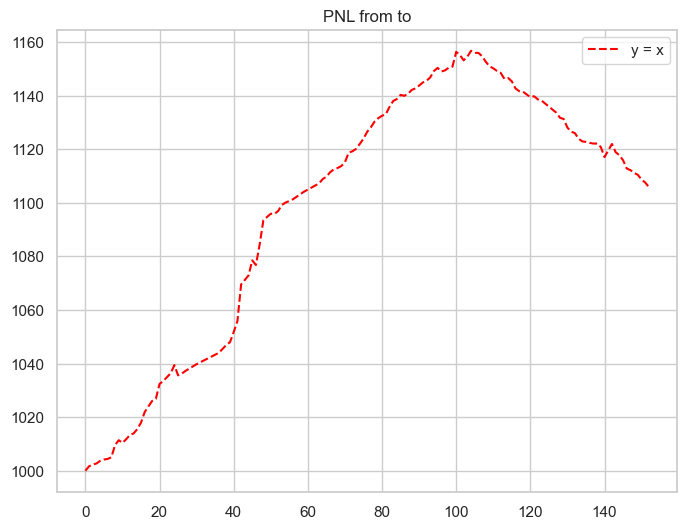

14 for this k/100 benchmark pnl is:


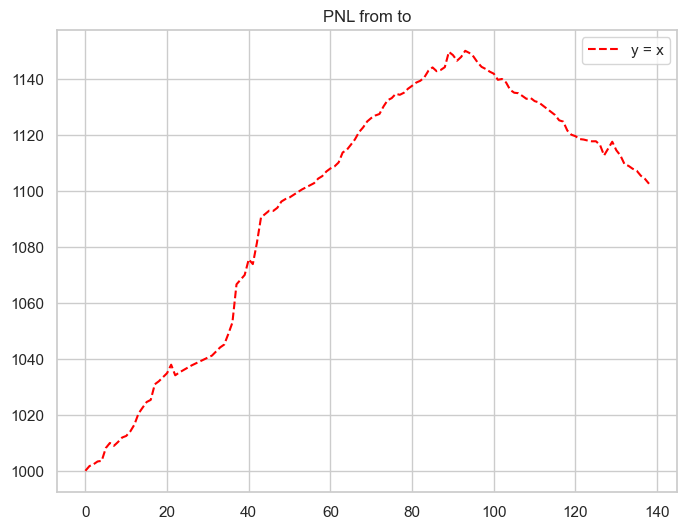

In [315]:
comission = 0.001

for k in range (7,15):
    pnl = np.array([1000])
    for i in range (1, len(predictions)):
        elem = predictions[i]
        if elem >= k/100:
            pnl  = np.append(pnl, pnl[len(pnl) - 1] * (1 + y_test.iloc[i]/100) * (1- comission))
        if elem < -1*k/100:
            pnl  = np.append(pnl, pnl[len(pnl) - 1] * (1 - y_test.iloc[i]/100) * (1 - comission))

    print(k, 'for this k/100 benchmark pnl is:')
    plt.figure(figsize=(8, 6))
    plt.plot(pnl, color='red', linestyle='--', label='y = x')

    # Adding labels and legend
    #plt.xlabel('test')
    #plt.ylabel('predictions')
    plt.title('PNL from to')
    plt.legend()

    # Show plot
    plt.show()


+ Biggest pnl is for the benchmark 0.01
+ If prediciton is near 0 better not to trade because of comission loss
+ big benchmark drops all value near 0 for which we are uncertain. 
+ Best result for k in [10;12]